# Ghost Analysis with Multi-Sequence Tracing

A ghost is a stray image formed when light partially reflects off two surfaces instead of refracting through them normally. Optiland models this with **multi-sequence tracing**: a sub-sequence traces the *same* surface objects as the main system, just in a different order, with an interaction override (`"reflect"`) at the bounce points.

This means the ghost sequence is never a separate, disconnected copy of the lens. Geometry and materials are shared by reference with the base `Optic`, so editing a surface (or optimizing it) is immediately visible in both the nominal system and every ghost sequence built over it.

In [1]:
from optiland.analysis import SpotDiagram
from optiland.samples.objectives import CookeTriplet

(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

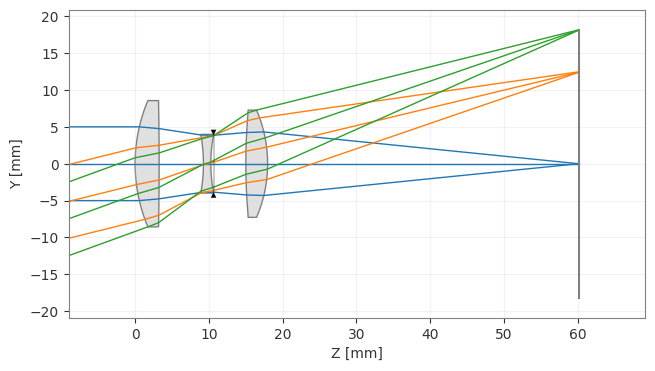

In [2]:
lens = CookeTriplet()
lens.draw()

## Defining the ghost sequence

`Optic.add_sequence` takes a list of steps. A bare surface index means "forward, normal refraction/reflection". An `(index, "reflect")` pair forces a reflection at that surface instead. The direction of travel (forward/reverse) is inferred automatically: it starts forward and flips every time the sequence reflects, since that is the point where the physical direction of propagation actually reverses.

Here we trace a classic two-bounce ghost: light refracts normally through surfaces 1 and 2, partially reflects off surface 3, travels back to partially reflect off surface 2, then continues forward through 3 to the image plane.

In [3]:
ghost = lens.add_sequence(
    "ghost_2_3",
    steps=[0, 1, 2, (3, "reflect"), (2, "reflect"), 3, 4, 5, 6, 7],
)
ghost

SequencedOptic(name='ghost_2_3', base_optic=<optiland.samples.objectives.CookeTriplet object at 0x0000026A110999D0>, steps=10)

Sequences are validated at construction time: if the interaction at any step would leave the ray in a medium that does not match what the next step expects, `add_sequence` raises immediately rather than silently tracing something unphysical.

## Tracing the ghost

Rays for the ghost sequence are generated exactly as they would be for the nominal system (same aperture stop, same conjugates, same ray aiming); only the path they take through the surfaces differs. Existing analyses like `SpotDiagram` work against a sequence the same way they work against an `Optic`, since a sequence exposes the same `trace`, `trace_generic`, and `surfaces` interface.

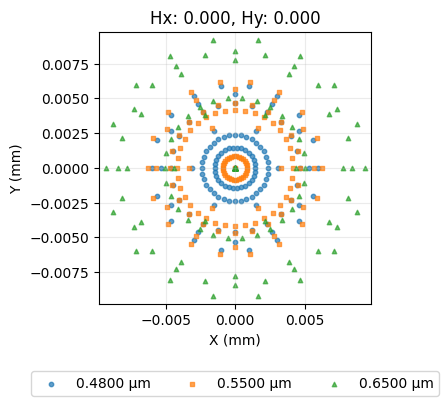

(<Figure size 1200x400 with 1 Axes>,
 [<Axes: title={'center': 'Hx: 0.000, Hy: 0.000'}, xlabel='X (mm)', ylabel='Y (mm)'>])

In [4]:
nominal_spot = SpotDiagram(lens, fields=[(0, 0)])
nominal_spot.view()

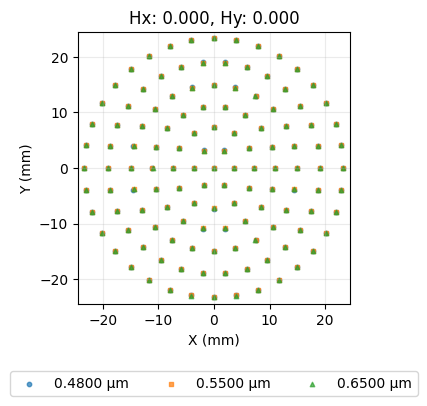

(<Figure size 1200x400 with 1 Axes>,
 [<Axes: title={'center': 'Hx: 0.000, Hy: 0.000'}, xlabel='X (mm)', ylabel='Y (mm)'>])

In [5]:
ghost_spot = SpotDiagram(ghost, fields=[(0, 0)])
ghost_spot.view()

The ghost spot lands in the same field of view as the real image, but is far larger and more diffuse, exactly the signature of a ghost image: a faint, out-of-focus blob rather than a sharp point. We can compare the two quantitatively with the RMS spot radius:

In [6]:
nominal_rms = nominal_spot.rms_spot_radius()[0][0]
ghost_rms = ghost_spot.rms_spot_radius()[0][0]

print(f"Nominal image RMS spot radius: {nominal_rms:.4f} mm")
print(f"Ghost RMS spot radius:         {ghost_rms:.4f} mm")
print(f"Ghost is {ghost_rms / nominal_rms:.0f}x larger")

Nominal image RMS spot radius: 0.0038 mm
Ghost RMS spot radius:         17.4720 mm
Ghost is 4608x larger


## The base system and the ghost stay linked

Because `SurfaceView` shares geometry with the base surfaces by reference, changing a base surface's radius updates the ghost trace too, without redefining the sequence.

In [7]:
original_radius = lens.surfaces.surfaces[2].geometry.radius
lens.surfaces.surfaces[2].geometry.radius = original_radius * 1.05

ghost_spot_after = SpotDiagram(ghost, fields=[(0, 0)])
print(f"Ghost RMS spot radius before edit: {ghost_rms:.4f} mm")
print(f"Ghost RMS spot radius after edit:  {ghost_spot_after.rms_spot_radius()[0][0]:.4f} mm")

lens.surfaces.surfaces[2].geometry.radius = original_radius

Ghost RMS spot radius before edit: 17.4720 mm
Ghost RMS spot radius after edit:  17.4683 mm


## Optimizing with the ghost in the loop

Since a sequence exposes the same `trace`-based interface as an `Optic`, ray operands like `rms_spot_size` work against it directly. That means a merit function can mix operands over the nominal system and a ghost sequence in the same `OptimizationProblem`, for example to keep the nominal image sharp while also constraining how tightly a ghost focuses.

In [8]:
from optiland.optimization import OptimizationProblem

problem = OptimizationProblem()
problem.add_operand(
    "rms_spot_size",
    target=0.0,
    weight=1.0,
    input_data={
        "optic": lens,
        "surface_number": -1,
        "Hx": 0.0,
        "Hy": 0.0,
        "num_rays": 20,
        "wavelength": 0.55,
    },
)
problem.add_operand(
    "rms_spot_size",
    min_val=0.5,
    weight=0.1,
    input_data={
        "optic": ghost,
        "surface_number": -1,
        "Hx": 0.0,
        "Hy": 0.0,
        "num_rays": 20,
        "wavelength": 0.55,
        "nan_policy": "omit",
    },
)
problem.operand_info()

╒════╤════════════════╤══════════╤══════════════╤══════════════╤══════════╤═══════════════╤═════════╤═════════╤════════════════╕
│    │ Operand Type   │ Target   │ Min. Bound   │ Max. Bound   │   Weight │   Eff. Weight │   Value │   Delta │   Contrib. [%] │
╞════╪════════════════╪══════════╪══════════════╪══════════════╪══════════╪═══════════════╪═════════╪═════════╪════════════════╡
│  0 │ rms spot size  │ +0.000   │              │              │      1   │           1   │   0.004 │   0.004 │            100 │
│  1 │ rms spot size  │          │ 0.5          │              │      0.1 │           0.1 │  16.558 │   0     │              0 │
╘════╧════════════════╧══════════╧══════════════╧══════════════╧══════════╧═══════════════╧═════════╧═════════╧════════════════╛


The second operand sets `min_val=0.5`, an inequality constraint asking the optimizer to keep the ghost spread over at least 0.5 mm, i.e. to keep it diffuse rather than letting it accidentally focus into a sharp secondary image. This is the kind of constraint that is only possible once the ghost path is a first-class part of the merit function, alongside the nominal image quality.